# House Price Prediction — Data Analyst Portfolio Project

## 1. Business Problem

Accurately estimating house sale prices helps real estate companies, buyers, and
sellers make informed pricing decisions. This project builds a regression model
to predict house sale prices based on property features, helping identify which
factors most strongly influence value.

## 2. Dataset Overview

- **Source:** Kaggle — House Prices: Advanced Regression Techniques (Ames Housing dataset)
- **Size:** 1,460 training rows, 79 explanatory features + target
- **Target column:** `SalePrice` (continuous, in dollars)
- **Key feature groups:**
  - Size/area: `GrLivArea`, `TotalBsmtSF`, `LotArea`, `GarageArea`
  - Quality/condition: `OverallQual`, `OverallCond`, `ExterQual`
  - Location/type: `Neighborhood`, `MSZoning`, `BldgType`
  - Age: `YearBuilt`, `YearRemodAdd`
  - Other: bathrooms, bedrooms, garage details, basement details, etc.

## 3. Data Loading & Initial Inspection

In [ ]:
# Load the dataset and take a first look

import pandas as pd   # pandas helps us work with tabular data (like Excel, but in code)

# Load the training CSV file into a DataFrame
df = pd.read_csv('/content/train.csv')

# 1. Check the shape (rows, columns) of the dataset
print("Shape of dataset:", df.shape)

# 2. Look at the first 5 rows to understand the data
df.head()

Shape of dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Check column names, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**Observation:** The training dataset contains 1,460 houses with 81 columns
(79 features plus `Id` and the target `SalePrice`). The dataset includes a mix
of numeric features (like `LotArea`, `YearBuilt`, `OverallQual`) and categorical
features (like `Neighborhood`, `BldgType`, `ExterQual`). Several columns show
missing values, which will be examined and addressed in the Data Cleaning section.

## 4. Data Cleaning

In [ ]:
# Check missing values across all columns, sorted from most to least missing
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:", len(missing))
print(missing)

Columns with missing values: 19
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


**Observation:** 19 columns contain missing values. The top few — `PoolQC`
(1,453 missing), `MiscFeature` (1,406), `Alley` (1,369), `Fence` (1,179), and
`FireplaceQu` (690) — are not truly "missing" data. In this dataset, a blank
value in these columns means the house simply doesn't have that feature (e.g.,
no pool, no alley access, no fence). The `Garage*` and `Bsmt*` columns (missing
~81 and ~37 rows respectively) follow the same pattern — missing means no garage
or no basement. `LotFrontage` (259 missing) and `MasVnrArea`/`MasVnrType` (8/872
missing) and `Electrical` (1 missing) are genuinely missing data points that
need different handling.

In [ ]:
# Group 1: Columns where missing = "feature doesn't exist" — fill with 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
             'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

print("Filled 'None' for", len(none_cols), "columns")

Filled 'None' for 15 columns


In [ ]:
# Group 2: Genuinely missing numeric values — fill with median or 0
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)   # 0 means no garage

# Group 3: Electrical — only 1 missing, fill with the most common value (mode)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Confirm no missing values remain
print("Total missing values remaining:", df.isnull().sum().sum())

Total missing values remaining: 0


**Observation:** Missing values were handled in three groups. Columns where a
blank meant "feature not present" (pool, fence, garage details, basement details,
etc.) were filled with `'None'`. Genuinely missing numeric values — `LotFrontage`
(filled with median), `MasVnrArea` (filled with 0), and `GarageYrBlt` (filled
with 0 for houses without a garage) — were handled based on context. The single
missing `Electrical` value was filled with the most common category. The dataset
now has 0 missing values and is ready for exploratory analysis.

## 5. Exploratory Data Analysis (EDA)

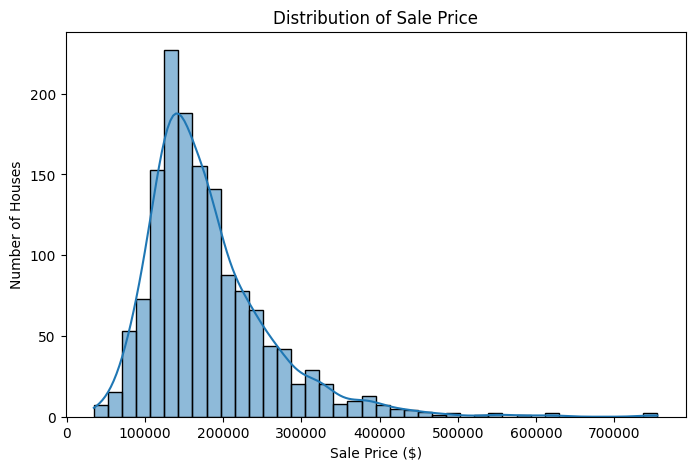

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [ ]:
import matplotlib.pyplot as plt   # for plotting charts
import seaborn as sns              # for nicer, easier statistical charts

# Check the distribution of the target variable: SalePrice
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, bins=40)
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.show()

# Also check basic statistics
print(df['SalePrice'].describe())

**Observation:** `SalePrice` ranges from $34,900 to $755,000, with a mean of
$180,921 and median of $163,000. Since the mean is notably higher than the
median, the distribution is **right-skewed** — most houses are priced in the
moderate range, with a smaller number of high-value homes pulling the average
up. This skew violates the assumption of normally distributed errors that
linear regression relies on, so we'll apply a **log transformation** to
`SalePrice` before modeling to make the distribution more symmetric and improve
model performance.

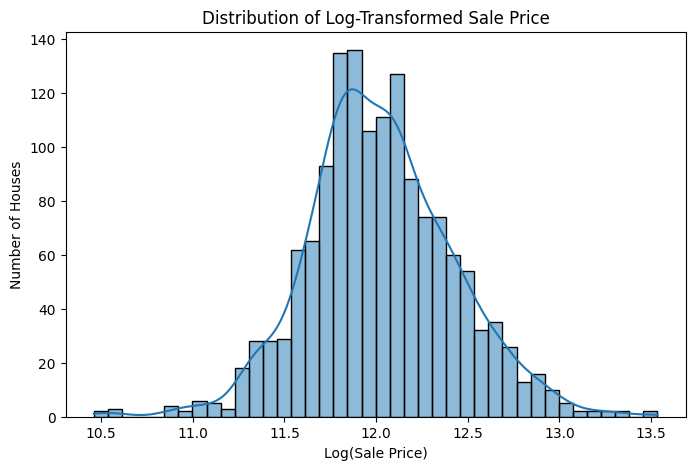

In [ ]:
import numpy as np

# Apply log transformation to SalePrice (log1p handles this safely, same as log(1+x))
df['SalePrice_log'] = np.log1p(df['SalePrice'])

plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice_log'], kde=True, bins=40)
plt.title('Distribution of Log-Transformed Sale Price')
plt.xlabel('Log(Sale Price)')
plt.ylabel('Number of Houses')
plt.show()

**Observation:** After applying a log transformation, `SalePrice_log` shows a
much more symmetric, bell-shaped distribution compared to the original
right-skewed `SalePrice`. This transformed target will be used for model
training, since regression models perform better and produce more reliable
predictions when the target variable is closer to normally distributed.
Predictions will be converted back to the original dollar scale when
interpreting results.

In [ ]:
# Check correlation of numeric features with SalePrice
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

print(correlations.head(11))   # top 10 + SalePrice itself

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
Name: SalePrice, dtype: float64


**Observation:** The features most strongly correlated with `SalePrice` are
**OverallQual** (0.79), **GrLivArea** — above-ground living area (0.71),
**GarageCars** (0.64), **GarageArea** (0.62), and **TotalBsmtSF** (0.61). This
indicates that overall build/material quality and the size of the house (living
area, garage, basement) are the strongest drivers of price — more so than age
(`YearBuilt`, 0.52) or room count (`TotRmsAbvGrd`, 0.53). These will likely be
the most important features in the final model.

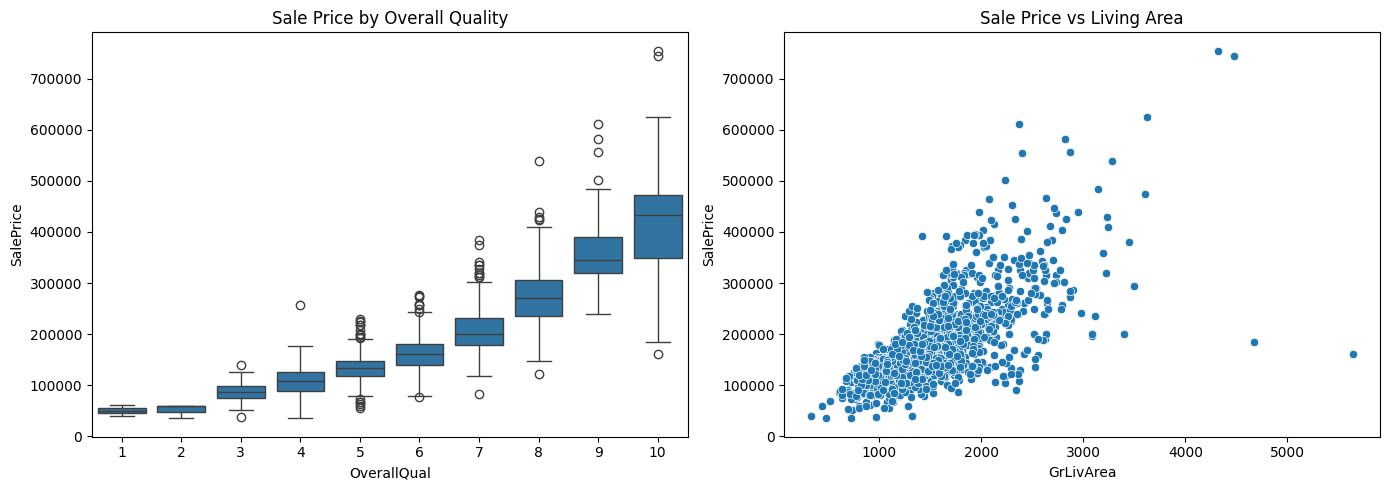

In [ ]:
# Visualize the two strongest relationships with SalePrice

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# OverallQual vs SalePrice (categorical-ish, use boxplot)
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0])
axes[0].set_title('Sale Price by Overall Quality')

# GrLivArea vs SalePrice (continuous, use scatterplot)
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=axes[1])
axes[1].set_title('Sale Price vs Living Area')

plt.tight_layout()
plt.show()

**Observation:** `OverallQual` shows a strong, clear step-wise relationship with
price — each quality tier increase corresponds to a noticeable jump in median
sale price. `GrLivArea` shows a strong positive trend with price, but two
notable **outliers** stand out: two houses with very large living areas
(4,700+ sq ft) sold for under $200,000, well below what their size would predict.
These are likely data quality issues or unusual sales (e.g., distressed sales)
and should be removed before modeling, since they could distort the regression line.

In [ ]:
# Remove the two known outliers: very large homes with unusually low sale price
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (1458, 82)


**Observation:** The two outlier houses (large living area, unusually low price)
were removed, reducing the dataset from 1,460 to 1,458 rows. This prevents these
unrepresentative data points from distorting the regression model's learned
relationships, particularly for the `GrLivArea` feature which showed a strong
otherwise-clean trend with price.

## 6. Feature Engineering & Preprocessing

In [ ]:
# Save the target separately BEFORE dropping it from df
y_target = df['SalePrice_log'].copy()

# Drop columns not useful for modeling (including the target, to avoid leakage)
df = df.drop(['Id', 'SalePrice', 'SalePrice_log'], axis=1)

categorical_cols = df.select_dtypes(include='object').columns
print("Number of categorical columns:", len(categorical_cols))

Number of categorical columns: 43


**Observation:** The dataset contains 43 categorical columns, nearly triple the
churn dataset's count. One-hot encoding all of them will significantly expand
the feature space (potentially 200+ columns), which increases the risk of the
model overfitting on a relatively small dataset (1,458 rows). We'll proceed with
one-hot encoding since tree-based models (which we'll use) handle high-dimensional
sparse data reasonably well, but this tradeoff is worth noting for future
improvement (e.g., grouping rare categories, or using target encoding instead).

In [ ]:
# One-hot encode all categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (1458, 258)


**Observation:** After one-hot encoding, the dataset expanded from 36 original
feature columns to 259, as expected given the large number of categorical
variables and their categories. This confirms the earlier concern about
dimensionality — with only 1,458 rows and 259 features, we'll need to watch
carefully for overfitting during model evaluation.

### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded
y = y_target   # use the separately saved target (created in the corrected Cell 18)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1166, 258)
Testing set shape: (292, 258)


**Observation:** The dataset was split into 1,166 training rows and 292 testing
rows (80/20 split), using the log-transformed `SalePrice_log` as the target.
We're now ready to build and compare regression models.

## 7. Model Building

In [ ]:
from sklearn.linear_model import LinearRegression

# Create and train a Linear Regression model — our baseline
model_lin = LinearRegression()
model_lin.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set (still in log scale)
y_pred_lin_log = model_lin.predict(X_test)

# Evaluate in log scale first
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_lin_log))
r2 = r2_score(y_test, y_pred_lin_log)

print("RMSE (log scale):", rmse_log)
print("R² Score:", r2)

# Convert predictions back to actual dollar scale for interpretability
y_pred_lin_actual = np.expm1(y_pred_lin_log)   # reverse of log1p
y_test_actual = np.expm1(y_test)

rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_lin_actual))
print("RMSE (actual $ scale):", rmse_actual)

RMSE (log scale): 0.13714217029624842
R² Score: 0.8884304679734876
RMSE (actual $ scale): 21891.014272279655


**Observation:** After correcting a data leakage issue (the target column had
accidentally been included as a feature), the baseline Linear Regression model
achieved an **R² score of 0.888** — meaning it explains about 89% of the
variation in house prices. The RMSE in actual dollar terms is approximately
**$21,891**, meaning predictions are off by about this amount on average. This
is a solid baseline, though Linear Regression can be sensitive to the high
number of features (259) relative to the number of training rows (1,166), so
we'll compare against Random Forest next to check for improvement and stability.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create and train a Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Predict (in log scale)
y_pred_rf_log = model_rf.predict(X_test)

# Evaluate in log scale
rmse_log_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_log))
r2_rf = r2_score(y_test, y_pred_rf_log)

print("RMSE (log scale):", rmse_log_rf)
print("R² Score:", r2_rf)

# Convert to actual dollar scale
y_pred_rf_actual = np.expm1(y_pred_rf_log)
rmse_actual_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_actual))
print("RMSE (actual $ scale):", rmse_actual_rf)

RMSE (log scale): 0.14692972745366464
R² Score: 0.8719372211082499
RMSE (actual $ scale): 24390.588752415326


**Observation:** Random Forest achieved an R² of 0.872 and RMSE of $24,391 —
slightly **worse** than Linear Regression (R² 0.888, RMSE $21,891) on this
dataset.

**Model comparison:**

| Metric | Linear Regression | Random Forest |
|---|---|---|
| R² Score | 0.888 | 0.872 |
| RMSE (log scale) | 0.137 | 0.147 |
| RMSE (actual $) | $21,891 | $24,391 |

**Model choice: Linear Regression performs better here.** This is a reasonable
outcome — after log-transforming the target and encoding features, many
relationships in this dataset (like `OverallQual` and `GrLivArea` vs price) are
fairly linear, which favors Linear Regression. Random Forest's strength in
capturing non-linear patterns doesn't provide enough benefit here to outweigh
Linear Regression's simplicity,

          Feature  Importance
3     OverallQual    0.520682
15      GrLivArea    0.114597
26     GarageArea    0.062999
11    TotalBsmtSF    0.053421
25     GarageCars    0.026899
8      BsmtFinSF1    0.022656
12       1stFlrSF    0.017960
194  CentralAir_Y    0.014366
5       YearBuilt    0.013615
2         LotArea    0.012433


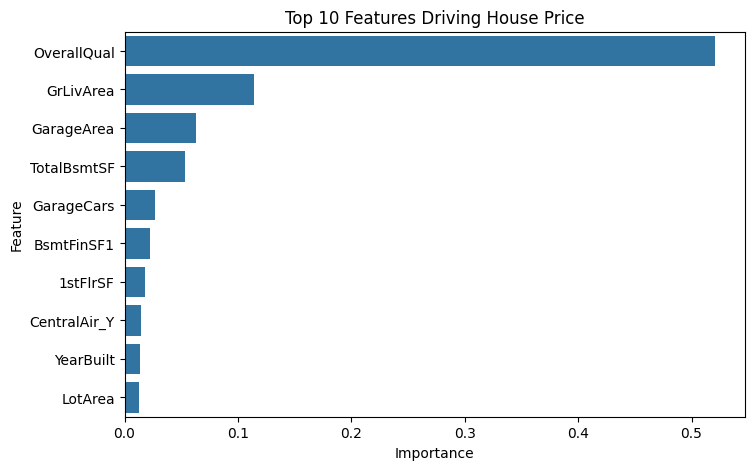

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Features Driving House Price')
plt.show()

**Observation:** `OverallQual` overwhelmingly dominates as the top driver of
house price, with an importance score more than 4x higher than the next feature,
`GrLivArea`. This confirms our earlier correlation analysis (0.79 correlation
for `OverallQual` vs 0.71 for `GrLivArea`). Size-related features — `GarageArea`,
`TotalBsmtSF`, `GarageCars`, `1stFlrSF` — form a consistent second tier,
reinforcing that build quality and square footage together explain most of the
variation in price. Interestingly, `CentralAir_Y` (having central air
conditioning) and `YearBuilt` also appear in the top 10, suggesting modern
amenities and house age still play a meaningful, secondary role.

## 8. Model Evaluation

**Final model selected: Linear Regression**

| Metric | Linear Regression | Random Forest |
|---|---|---|
| R² Score | **0.888** | 0.872 |
| RMSE (log scale) | 0.137 | 0.147 |
| RMSE (USD) | **21,891** | 24,391 |

Linear Regression was selected as the final model, achieving a higher R² and
lower error than Random Forest. This suggests the relationships between house
features and price in this dataset are largely linear once the target is
log-transformed and features are properly encoded.

## 9. Business Insights & Recommendations

**Key findings:**
1. **Overall quality is the single strongest price driver** — by a wide margin
   over any other feature. *Recommendation: for renovation ROI, prioritize
   quality-related improvements (materials, finishes) over adding square footage alone.*
2. **Living area and basement/garage size are the next strongest drivers** —
   *Recommendation: for pricing strategy, size-adjusted comparisons within a
   quality tier will be more accurate than flat per-square-foot pricing.*
3. **Central air conditioning has a measurable impact on price** — a relatively
   low-cost upgrade with outsized influence for older homes without it.
4. **Two outlier sales (large homes, unusually low price) were identified and
   removed** — worth flagging as either distressed sales or data entry errors
   for further investigation.

**Business impact:** This model can help real estate agents and sellers estimate
a data-driven listing price within roughly ±$22,000, and helps homeowners
understand which renovations offer the best return relative to price impact.

## 10. Conclusion & Next Steps

This project built a Linear Regression model to predict house sale prices with
an R² of 0.888, identifying overall quality and living area as the dominant
price drivers — insights directly usable for pricing and renovation decisions.

**Next steps:**
- Apply regularization (Ridge/Lasso) to reduce overfitting risk given the high
  feature-to-row ratio
- Try gradient boosting models (XGBoost, LightGBM) for potential further improvement
- Group rare categorical values to reduce dimensionality from one-hot encoding
- Deploy as a Streamlit app for interactive price estimation